#Decision Tree


Flow Chart Model

| Age | Weight | Smoker | Risk      |
| --- | ------ | ------ | --------- |
| 15  | 45     | No     | Low Risk  |
| 16  | 50     | Yes    | Low Risk  |
| 17  | 55     | No     | Low Risk  |
| 14  | 58     | Yes    | Low Risk  |
| 15  | 65     | No     | High Risk |
| 16  | 70     | Yes    | High Risk |
| 17  | 80     | No     | High Risk |
| 17  | 62     | Yes    | High Risk |
| 18  | 55     | No     | Low Risk  |
| 20  | 70     | Yes    | Low Risk  |
| 22  | 80     | No     | Low Risk  |
| 25  | 65     | Yes    | Low Risk  |
| 28  | 90     | No     | Low Risk  |
| 31  | 75     | No     | Low Risk  |
| 35  | 85     | No     | Low Risk  |
| 40  | 95     | No     | Low Risk  |
| 45  | 70     | No     | Low Risk  |
| 32  | 60     | Yes    | High Risk |
| 38  | 80     | Yes    | High Risk |
| 50  | 90     | Yes    | High Risk |
| 55  | 100    | Yes    | High Risk |
| 65  | 75     | Yes    | High Risk |



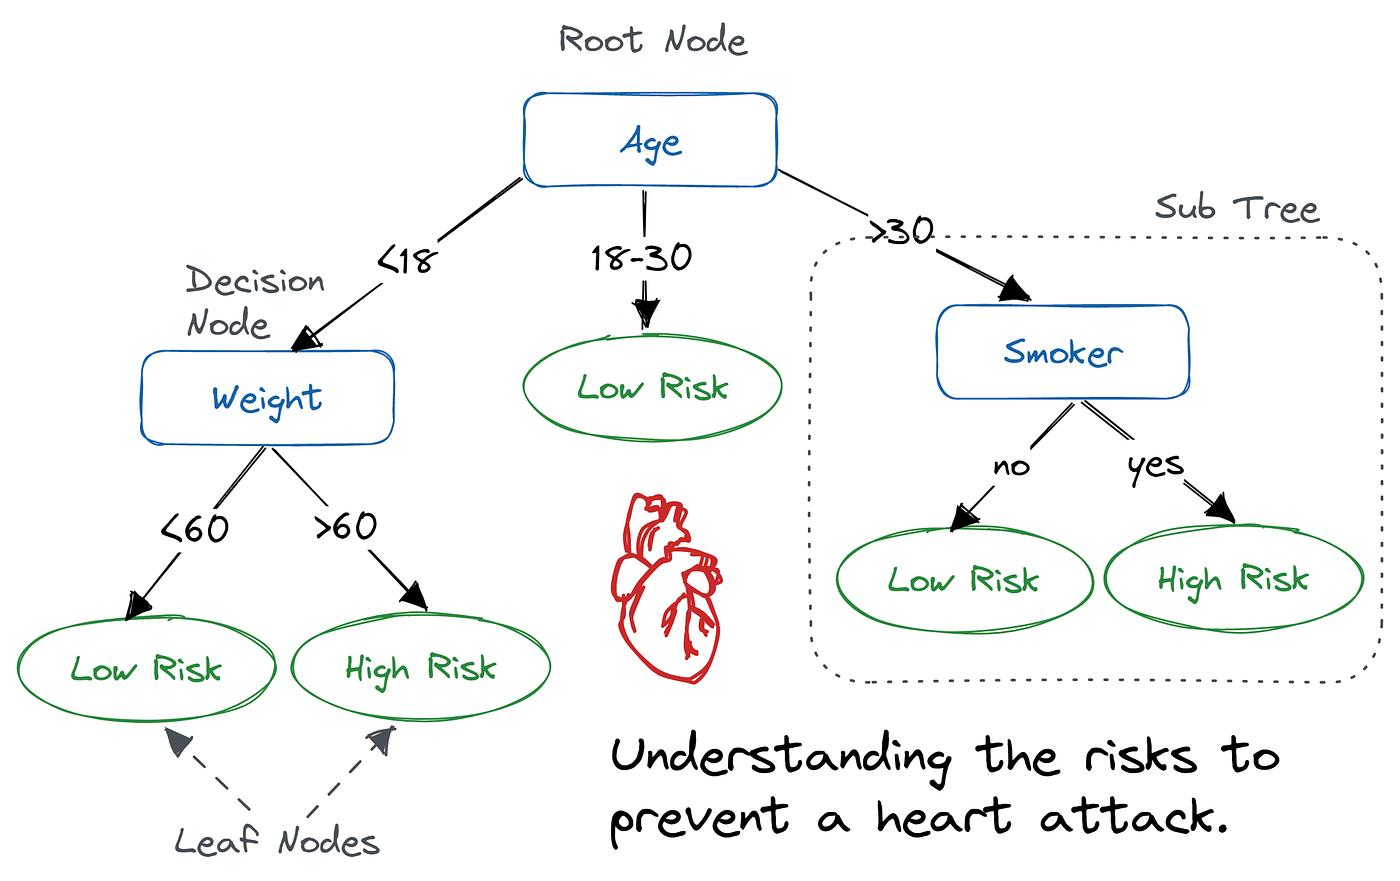

1. Root Node
2. Internal/Child Node
3. Leaf Node

## How To split the tree ?
1. Gini Index : Classification
2. Entopy + Information Gain : Classification
3. MSE+Variance : Regression

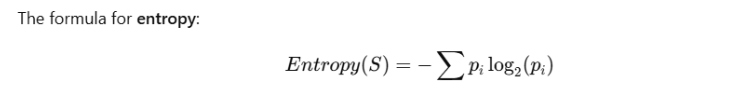

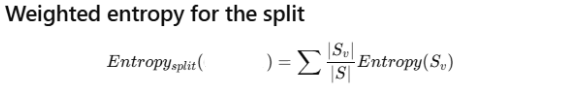

| Age | Income | Student | Credit_Rating | Buy_Product |
| --- | ------ | ------- | ------------- | ----------- |
| 22  | Low    | No      | Fair          | No          |
| 25  | Low    | Yes     | Excellent     | Yes         |
| 30  | Medium | No      | Fair          | Yes         |
| 35  | High   | Yes     | Fair          | Yes         |
| 40  | High   | No      | Excellent     | Yes         |
| 28  | Medium | Yes     | Poor          | No          |
| 50  | High   | No      | Poor          | No          |
| 23  | Low    | Yes     | Fair          | Yes         |


In [1]:
# Import libraries
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, export_text, plot_tree
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

In [2]:
df=pd.read_excel("/content/DT.xlsx")

In [3]:
df

,Age,Income,region,Credit_Rating,Buy_Product
0,22,Low,USA,Fair,No
1,25,Low,Canada,Excellent,Yes
2,30,Medium,USA,Fair,Yes
3,35,High,Canada,Fair,Yes
4,40,High,USA,Excellent,Yes
5,28,Medium,Canada,Poor,No
6,50,High,USA,Poor,No
7,23,Low,Canada,Fair,Yes


In [4]:
df.replace({ 'Income' : {'Low' : 0, 'Medium' : 1, 'High' : 2 } },inplace=True)

/tmp/ipykernel_4876/3617539698.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df.replace({ 'Income' : {'Low' : 0, 'Medium' : 1, 'High' : 2 } },inplace=True)


In [5]:
df

,Age,Income,region,Credit_Rating,Buy_Product
0,22,0,USA,Fair,No
1,25,0,Canada,Excellent,Yes
2,30,1,USA,Fair,Yes
3,35,2,Canada,Fair,Yes
4,40,2,USA,Excellent,Yes
5,28,1,Canada,Poor,No
6,50,2,USA,Poor,No
7,23,0,Canada,Fair,Yes


In [6]:
df.replace({ 'Credit_Rating' : {'Poor' : 0, 'Fair' : 1, 'Excellent' : 2 } },inplace=True)
df

/tmp/ipykernel_4876/1056020980.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df.replace({ 'Credit_Rating' : {'Poor' : 0, 'Fair' : 1, 'Excellent' : 2 } },inplace=True)


,Age,Income,region,Credit_Rating,Buy_Product
0,22,0,USA,1,No
1,25,0,Canada,2,Yes
2,30,1,USA,1,Yes
3,35,2,Canada,1,Yes
4,40,2,USA,2,Yes
5,28,1,Canada,0,No
6,50,2,USA,0,No
7,23,0,Canada,1,Yes


In [7]:
df.replace({ 'Buy_Product' : {'No' : 0, 'Yes' : 1 } },inplace=True)
df

/tmp/ipykernel_4876/2258164899.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df.replace({ 'Buy_Product' : {'No' : 0, 'Yes' : 1 } },inplace=True)


,Age,Income,region,Credit_Rating,Buy_Product
0,22,0,USA,1,0
1,25,0,Canada,2,1
2,30,1,USA,1,1
3,35,2,Canada,1,1
4,40,2,USA,2,1
5,28,1,Canada,0,0
6,50,2,USA,0,0
7,23,0,Canada,1,1


In [8]:
df=pd.get_dummies(df,dtype=int)

In [9]:
df

,Age,Income,Credit_Rating,Buy_Product,region_Canada,region_USA
0,22,0,1,0,0,1
1,25,0,2,1,1,0
2,30,1,1,1,0,1
3,35,2,1,1,1,0
4,40,2,2,1,0,1
5,28,1,0,0,1,0
6,50,2,0,0,0,1
7,23,0,1,1,1,0


In [10]:
x=df.drop("Buy_Product",axis=1)
y=df["Buy_Product"]

In [11]:
# Step 2: Split into train and test sets
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

#Model

In [49]:
# Step 3: Create Decision Tree Classifier
clf = DecisionTreeClassifier(criterion='entropy', max_depth=3, random_state=42)

In [50]:
# Step 4: Train the model
clf.fit(X_train, y_train)


DecisionTreeClassifier(criterion='entropy', max_depth=3, random_state=42)

In [51]:
# Step 5: Make predictions
y_pred = clf.predict(X_test)

In [52]:
# Step 6: Evaluate accuracy
accuracy = accuracy_score(y_test, y_pred)
print("Decision Tree Classification Accuracy:", accuracy)


Decision Tree Classification Accuracy: 1.0


In [53]:
# Step 7: Print the tree in text form
tree_rules = export_text(clf, feature_names=x.columns)
print("\nDecision Tree Rules:\n")
print(tree_rules)


Decision Tree Rules:

|--- Age <= 22.50
|   |--- class: 0
|--- Age >  22.50
|   |--- Credit_Rating <= 0.50
|   |   |--- class: 0
|   |--- Credit_Rating >  0.50
|   |   |--- class: 1



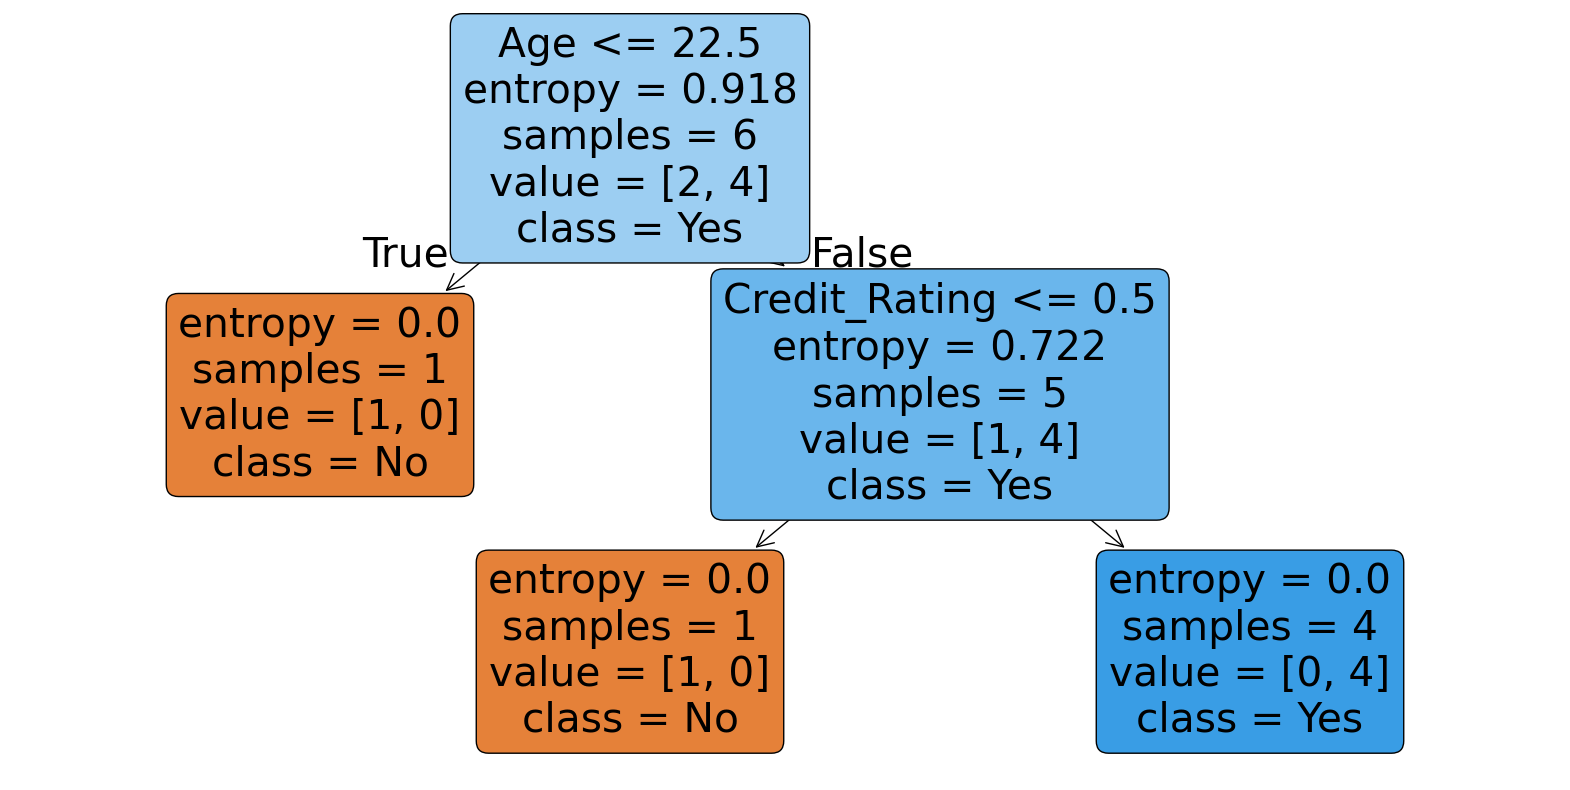

In [54]:
plt.figure(figsize=(20,10))
plot_tree(clf,
          feature_names=x.columns,
          class_names=["No", "Yes"],
          filled=True,
          rounded=True)

plt.show()

In [55]:
data = pd.read_csv('/content/iris.csv')

In [56]:
data

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,2
146,6.3,2.5,5.0,1.9,2
147,6.5,3.0,5.2,2.0,2
148,6.2,3.4,5.4,2.3,2


In [57]:
x=data.drop("target",axis=1)
y=data["target"]

In [58]:
# Step 2: Split into train and test sets
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [68]:
# Step 3: Create Decision Tree Classifier
clf = DecisionTreeClassifier(criterion='entropy', max_depth=4, random_state=42)

In [69]:
# Step 4: Train the model
clf.fit(X_train, y_train)


DecisionTreeClassifier(criterion='entropy', max_depth=4, random_state=42)

In [70]:
# Step 5: Make predictions
y_pred = clf.predict(X_test)

In [71]:
# Step 6: Evaluate accuracy
accuracy = accuracy_score(y_test, y_pred)
print("Decision Tree Classification Accuracy:", accuracy)


Decision Tree Classification Accuracy: 1.0


In [72]:



# Step 7: Print the tree in text form
tree_rules = export_text(clf, feature_names=x.columns)
print("\nDecision Tree Rules:\n")
print(tree_rules)


Decision Tree Rules:

|--- petal length (cm) <= 2.45
|   |--- class: 0
|--- petal length (cm) >  2.45
|   |--- petal length (cm) <= 4.75
|   |   |--- petal width (cm) <= 1.65
|   |   |   |--- class: 1
|   |   |--- petal width (cm) >  1.65
|   |   |   |--- class: 2
|   |--- petal length (cm) >  4.75
|   |   |--- petal width (cm) <= 1.75
|   |   |   |--- petal length (cm) <= 4.95
|   |   |   |   |--- class: 1
|   |   |   |--- petal length (cm) >  4.95
|   |   |   |   |--- class: 2
|   |   |--- petal width (cm) >  1.75
|   |   |   |--- petal length (cm) <= 4.85
|   |   |   |   |--- class: 2
|   |   |   |--- petal length (cm) >  4.85
|   |   |   |   |--- class: 2



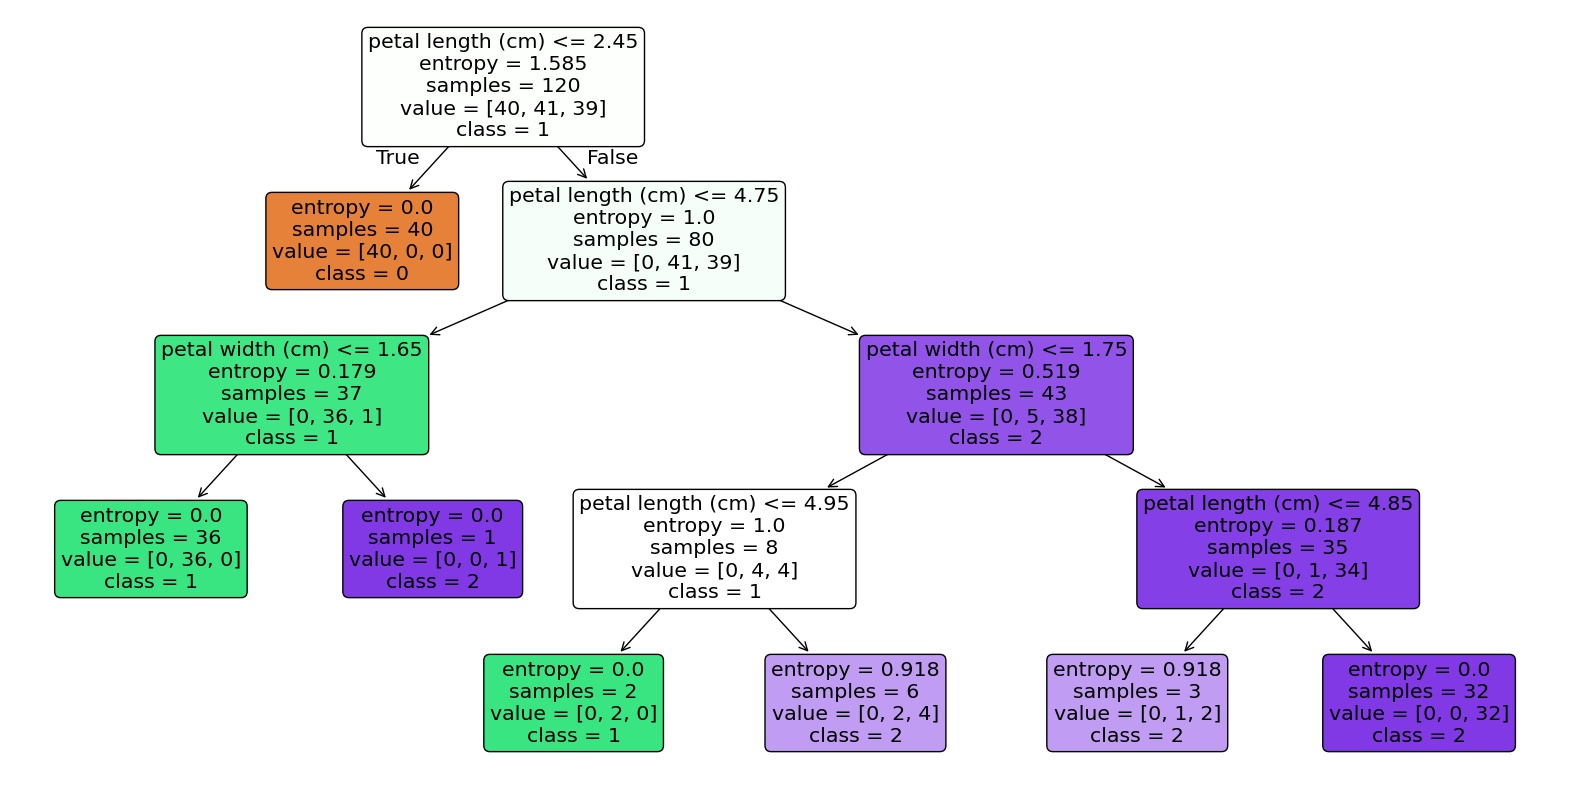

In [73]:
plt.figure(figsize=(20,10))
plot_tree(clf,
          feature_names=x.columns,
          class_names=["0", "1","2"],
          filled=True,
          rounded=True)

plt.show()

#Regression

In [105]:
data=pd.read_excel("/content/my_data.xlsx")

In [106]:
data

,Home_NUM,Area,Bedrooms,Age_of_Home,Price
0,1,1850,3,12,345000
1,2,1200,2,25,215500
2,3,3200,4,5,610750
3,4,1500,3,18,280900
4,5,2100,3,10,395000
5,6,980,2,30,185000
6,7,2750,4,8,520300
7,8,1600,3,20,295600
8,9,2400,4,15,455000
9,10,1100,2,28,205400


In [107]:
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.metrics import mean_squared_error

In [108]:
data

,Home_NUM,Area,Bedrooms,Age_of_Home,Price
0,1,1850,3,12,345000
1,2,1200,2,25,215500
2,3,3200,4,5,610750
3,4,1500,3,18,280900
4,5,2100,3,10,395000
5,6,980,2,30,185000
6,7,2750,4,8,520300
7,8,1600,3,20,295600
8,9,2400,4,15,455000
9,10,1100,2,28,205400


In [109]:
x=data.drop("Price",axis=1)
y=data["Price"]

In [110]:
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [111]:
from sklearn.preprocessing import MinMaxScaler, StandardScaler

In [112]:
stand = StandardScaler()
stand.fit(X_train)
X_train=stand.transform(X_train)

In [113]:
# Create Decision Tree Regressor
reg_tree = DecisionTreeRegressor(criterion='squared_error', max_depth=3, random_state=42)

# Train
reg_tree.fit(X_train, y_train)

# Predict
y_pred = reg_tree.predict(X_test)

# Evaluate
mse = mean_squared_error(y_test, y_pred)
print("Decision Tree Regression MSE:", mse)


Decision Tree Regression MSE: 111661602500.0


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but DecisionTreeRegressor was fitted without feature names
  warnings.warn(


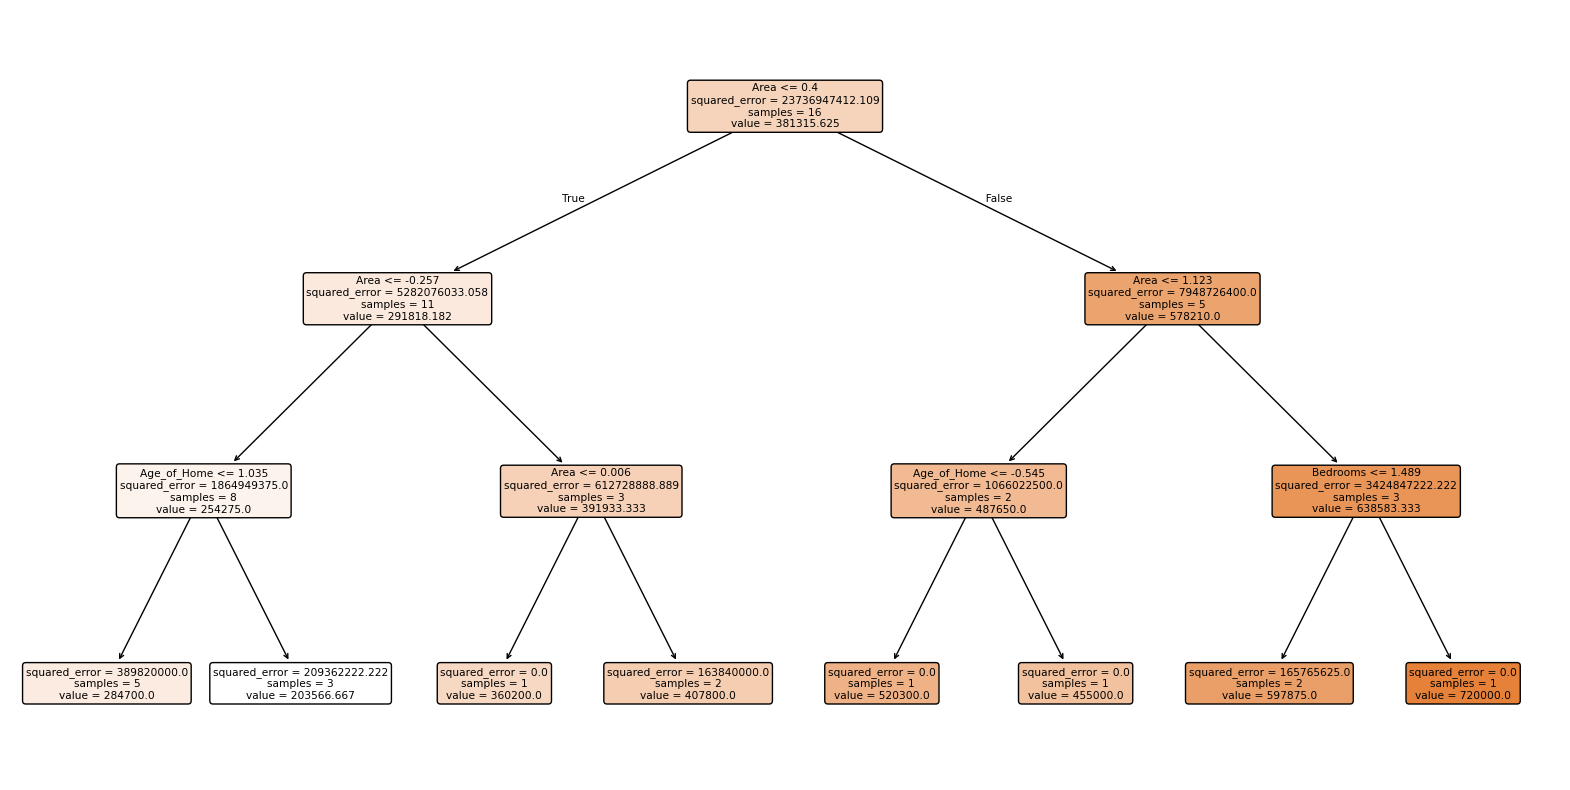

In [114]:
plt.figure(figsize=(20,10))
plot_tree(
    reg_tree,
    feature_names=x.columns,
    filled=True,
    rounded=True
)

plt.show()

In [115]:



# Step 7: Print the tree in text form
tree_rules = export_text(clf, feature_names=x.columns)
print("\nDecision Tree Rules:\n")
print(tree_rules)


Decision Tree Rules:

|--- Bedrooms <= 2.45
|   |--- class: 0
|--- Bedrooms >  2.45
|   |--- Bedrooms <= 4.75
|   |   |--- Age_of_Home <= 1.65
|   |   |   |--- class: 1
|   |   |--- Age_of_Home >  1.65
|   |   |   |--- class: 2
|   |--- Bedrooms >  4.75
|   |   |--- Age_of_Home <= 1.75
|   |   |   |--- Bedrooms <= 4.95
|   |   |   |   |--- class: 1
|   |   |   |--- Bedrooms >  4.95
|   |   |   |   |--- class: 2
|   |   |--- Age_of_Home >  1.75
|   |   |   |--- Bedrooms <= 4.85
|   |   |   |   |--- class: 2
|   |   |   |--- Bedrooms >  4.85
|   |   |   |   |--- class: 2

